# Iris Flower Classification  
**Models:** KNN & Random Forest | **Evaluation:** Test Data Only

## Cell 1 — Library Import

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Cell 2 — Dataset Load & Preview

In [21]:
df = pd.read_csv('/kaggle/input/datasets/saurabh00007/iriscsv/Iris.csv')

if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

print('--- First 5 Rows ---')
display(df.head())
print(f'\n--- Dataset Shape: {df.shape} ---')
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Class Distribution ---')
print(df['Species'].value_counts())

--- First 5 Rows ---


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



--- Dataset Shape: (150, 5) ---

--- Missing Values ---
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

--- Class Distribution ---
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## Cell 3 — EDA: Statistical Summary & Distributions

--- Statistical Summary ---


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


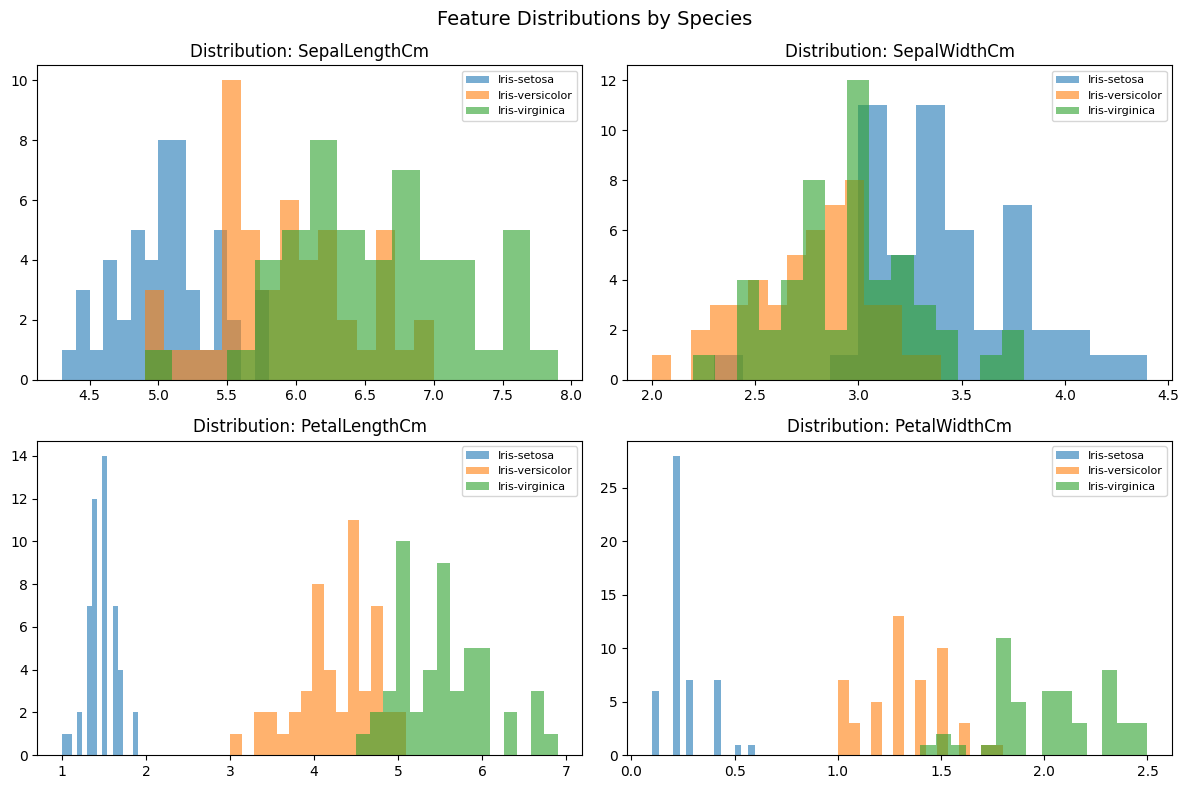

In [22]:
print('--- Statistical Summary ---')
display(df.describe())

features = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    for species, grp in df.groupby('Species'):
        ax.hist(grp[feat], alpha=0.6, label=species, bins=15)
    ax.set_title(f'Distribution: {feat}')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Species', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 4 — EDA: Pairplot & Correlation Heatmap

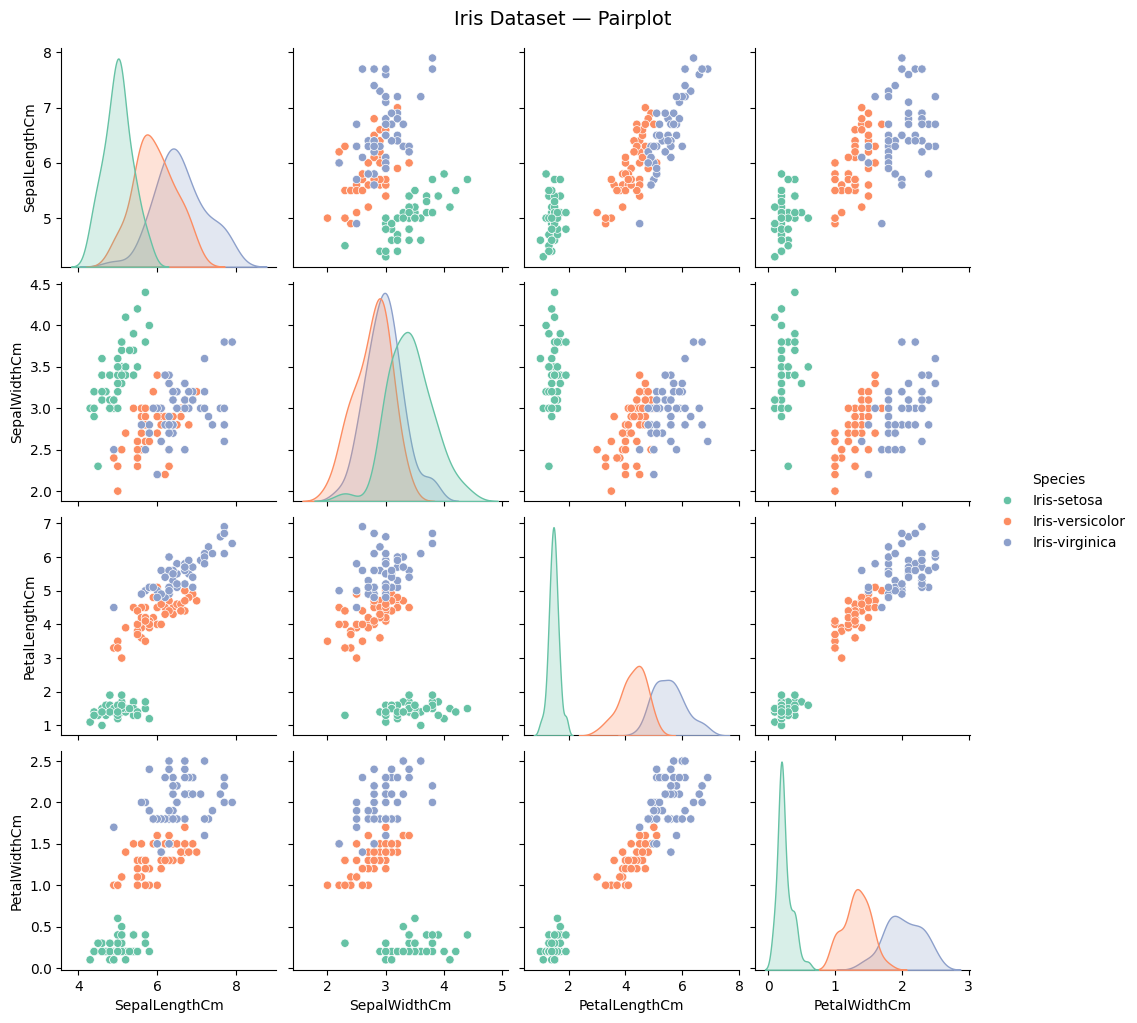

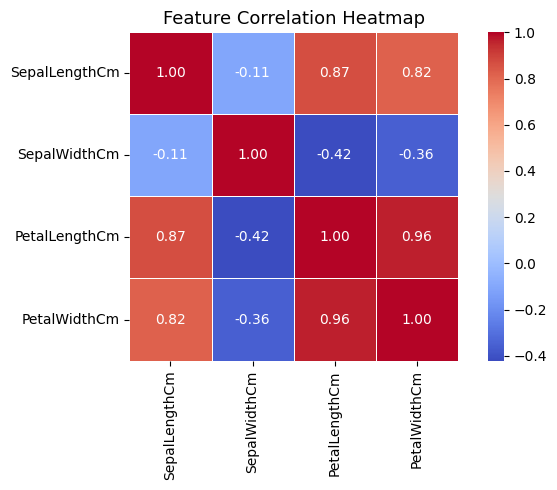

In [23]:
sns.pairplot(df, hue='Species', palette='Set2', diag_kind='kde')
plt.suptitle('Iris Dataset — Pairplot', y=1.02, fontsize=14)
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(
    df[features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True
)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 5 — EDA: Boxplots by Species

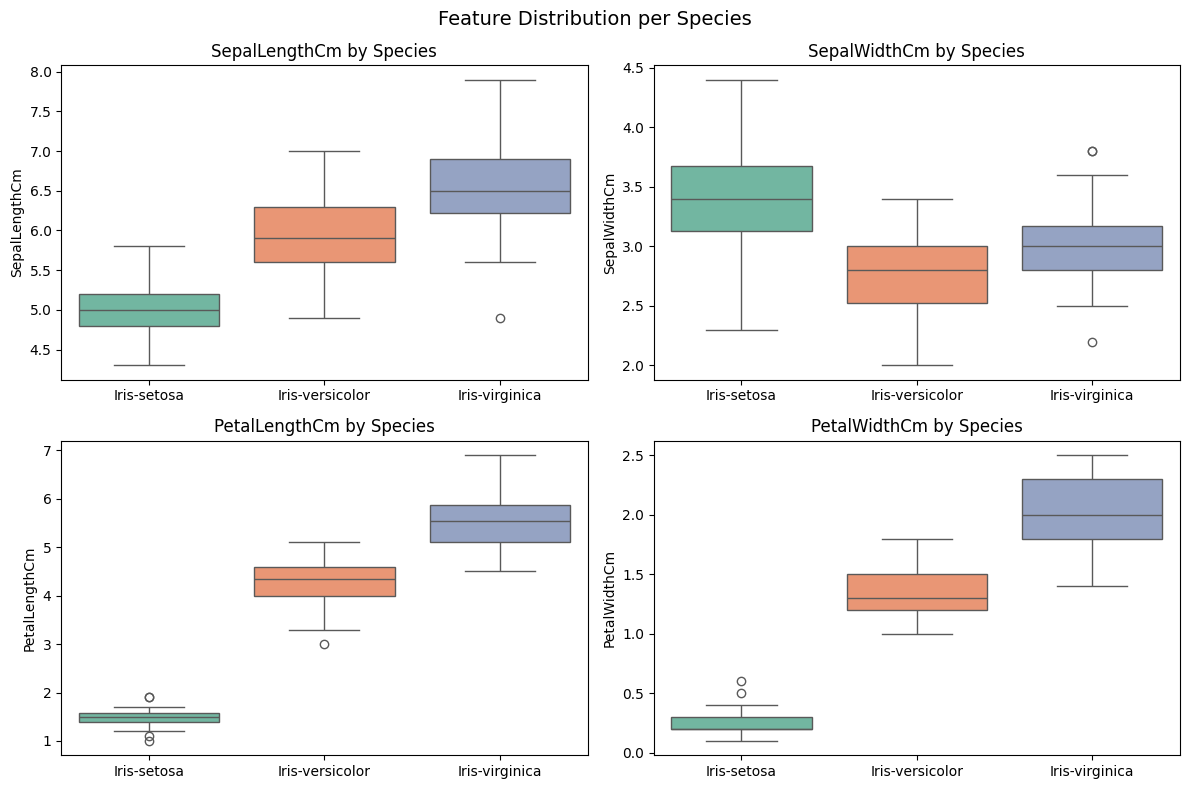

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='Species', y=feat, palette='Set2', ax=ax)
    ax.set_title(f'{feat} by Species')
    ax.set_xlabel('')

plt.suptitle('Feature Distribution per Species', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 6 — Feature Split + Train/Test Split

In [25]:
X = df[features]
y = df['Species']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=0, stratify=y_encoded
)

print(f'Train samples : {X_train.shape[0]}')
print(f'Test samples  : {X_test.shape[0]}')
print(f'Classes       : {le.classes_}')

Train samples : 120
Test samples  : 30
Classes       : ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


## Cell 7 — Model 1: KNN (Test Data)

In [26]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn   = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f'KNN Test Accuracy: {knn_accuracy*100:.2f}%')

KNN Test Accuracy: 96.67%


## Cell 8 — KNN: Classification Report + Confusion Matrix

=== KNN Classification Report (Test Data) ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



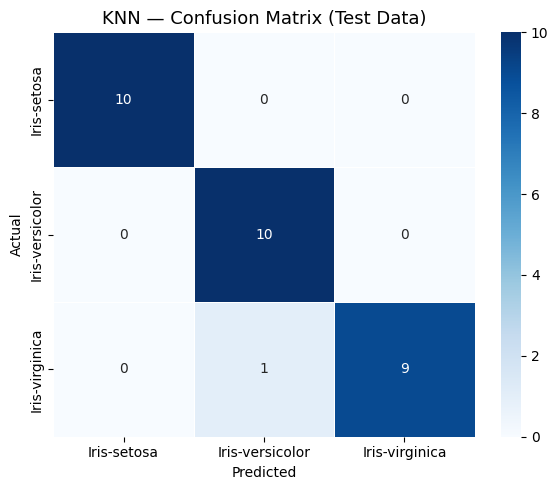

In [27]:
print('=== KNN Classification Report (Test Data) ===')
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

plt.figure(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(
    cm_knn, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5
)
plt.title('KNN — Confusion Matrix (Test Data)', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Cell 9 — KNN: Cross Validation + Accuracy & Loss Curve

Best K : 6  |  Best CV Accuracy : 96.67%


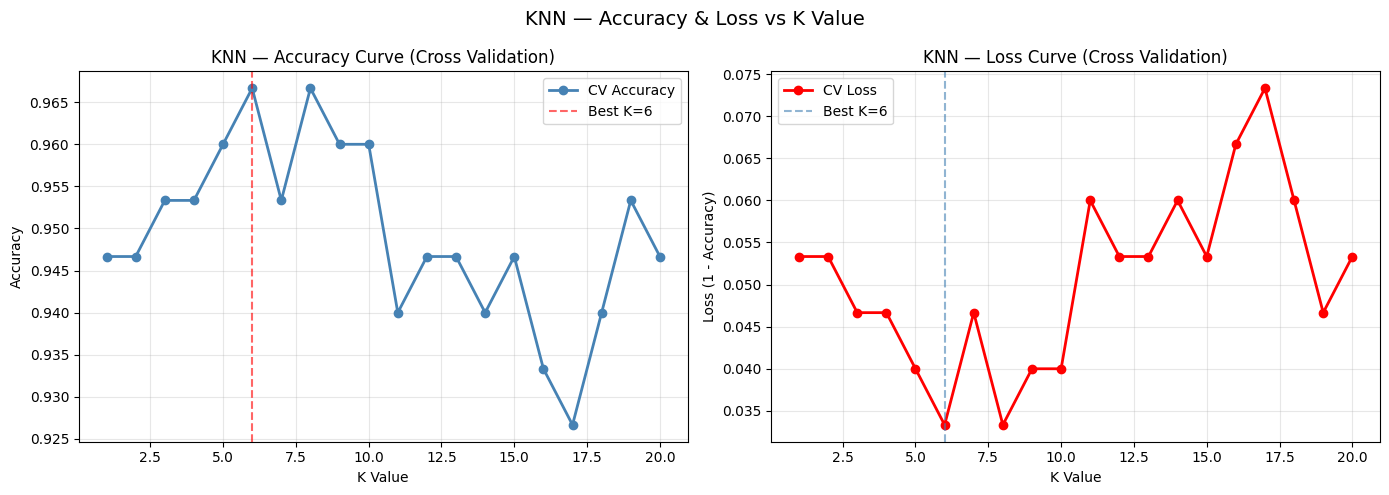

In [28]:
k_values        = range(1, 21)
accuracy_scores = []
loss_scores     = []

for k in k_values:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_scaled, y_encoded, cv=5)
    accuracy_scores.append(scores.mean())
    loss_scores.append(1 - scores.mean())

best_k = list(k_values)[accuracy_scores.index(max(accuracy_scores))]
print(f'Best K : {best_k}  |  Best CV Accuracy : {max(accuracy_scores)*100:.2f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_values, accuracy_scores, marker='o', color='steelblue', linewidth=2, label='CV Accuracy')
ax1.axvline(x=best_k, color='red', linestyle='--', alpha=0.6, label=f'Best K={best_k}')
ax1.set_title('KNN — Accuracy Curve (Cross Validation)')
ax1.set_xlabel('K Value')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(k_values, loss_scores, marker='o', color='red', linewidth=2, label='CV Loss')
ax2.axvline(x=best_k, color='steelblue', linestyle='--', alpha=0.6, label=f'Best K={best_k}')
ax2.set_title('KNN — Loss Curve (Cross Validation)')
ax2.set_xlabel('K Value')
ax2.set_ylabel('Loss (1 - Accuracy)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('KNN — Accuracy & Loss vs K Value', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 10 — KNN: ROC Curve (Test Data)

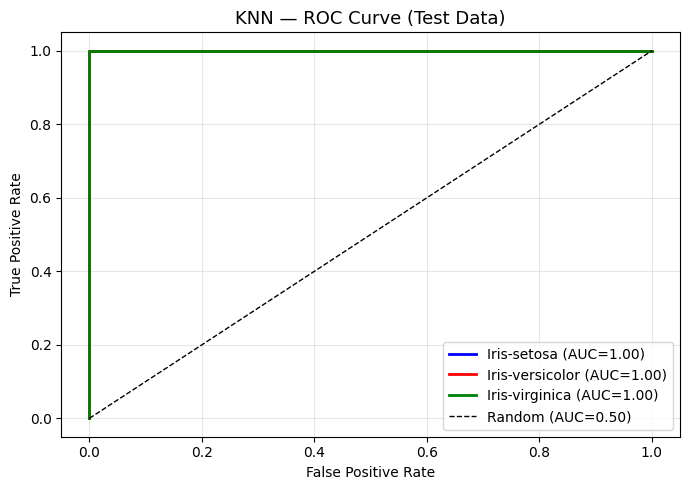

In [29]:
y_prob_knn = knn.predict_proba(X_test)
y_test_bin = np.eye(3)[y_test]

plt.figure(figsize=(7, 5))
colors_roc = ['blue', 'red', 'green']
for i, (color, cls) in enumerate(zip(colors_roc, le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.50)')
plt.title('KNN — ROC Curve (Test Data)', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 11 — Model 2: Random Forest (Test Data)
Classification Report + Confusion Matrix

Random Forest Test Accuracy: 100.00%
=== Random Forest Classification Report (Test Data) ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



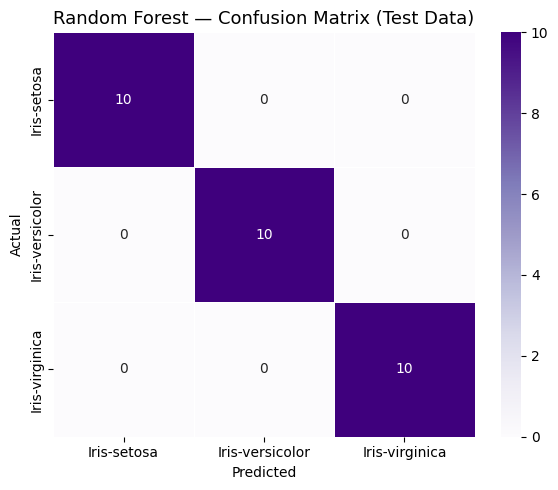

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf   = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest Test Accuracy: {rf_accuracy*100:.2f}%')
print('=== Random Forest Classification Report (Test Data) ===')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap='Purples',
    xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5
)
plt.title('Random Forest — Confusion Matrix (Test Data)', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Cell 12- Random Forest: Cross Validation + Accuracy & Loss Curve, ROC curve

Best n_estimators : 50  |  Best CV Accuracy : 96.00%


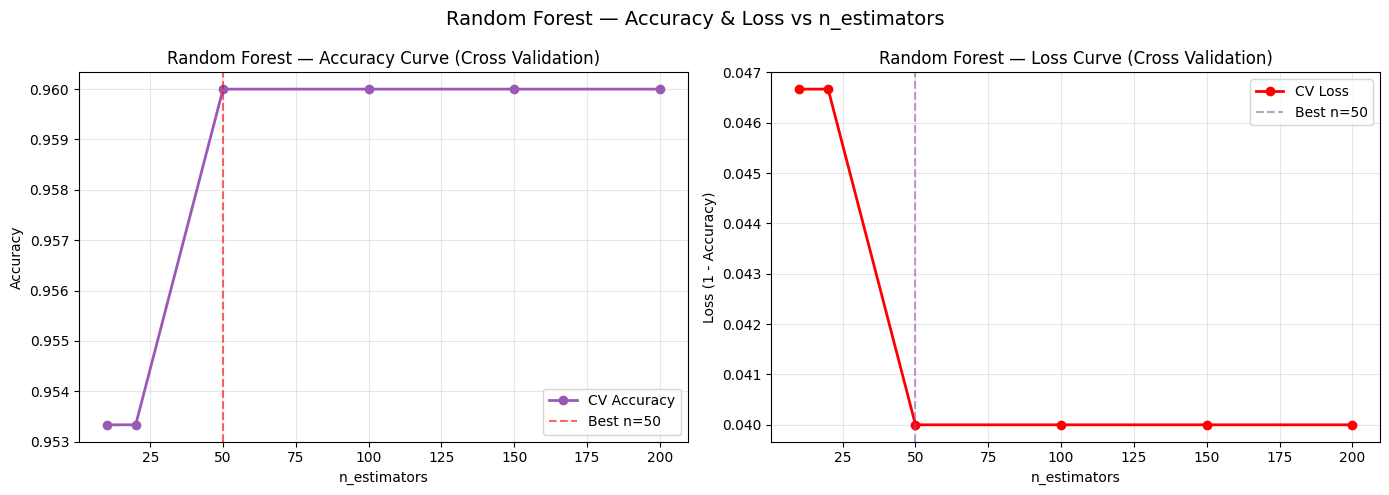

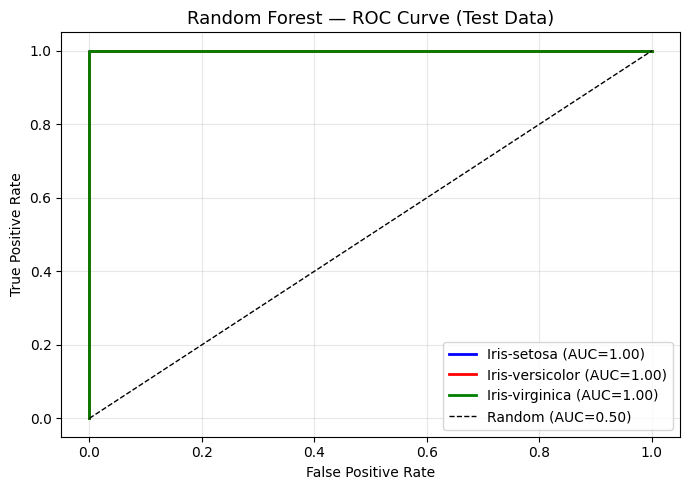

In [35]:
n_values      = [10, 20, 50, 100, 150, 200]
rf_acc_scores = []
rf_loss_scores= []

for n in n_values:
    scores = cross_val_score(RandomForestClassifier(n_estimators=n, random_state=42), X_scaled, y_encoded, cv=5)
    rf_acc_scores.append(scores.mean())
    rf_loss_scores.append(1 - scores.mean())

best_n = n_values[rf_acc_scores.index(max(rf_acc_scores))]
print(f'Best n_estimators : {best_n}  |  Best CV Accuracy : {max(rf_acc_scores)*100:.2f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(n_values, rf_acc_scores, marker='o', color='#9b59b6', linewidth=2, label='CV Accuracy')
ax1.axvline(x=best_n, color='red', linestyle='--', alpha=0.6, label=f'Best n={best_n}')
ax1.set_title('Random Forest — Accuracy Curve (Cross Validation)')
ax1.set_xlabel('n_estimators')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(n_values, rf_loss_scores, marker='o', color='red', linewidth=2, label='CV Loss')
ax2.axvline(x=best_n, color='#9b59b6', linestyle='--', alpha=0.6, label=f'Best n={best_n}')
ax2.set_title('Random Forest — Loss Curve (Cross Validation)')
ax2.set_xlabel('n_estimators')
ax2.set_ylabel('Loss (1 - Accuracy)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Random Forest — Accuracy & Loss vs n_estimators', fontsize=14)
plt.tight_layout()
plt.show()
y_prob_rf = rf.predict_proba(X_test)

plt.figure(figsize=(7, 5))
colors_roc = ['blue', 'red', 'green']
for i, (color, cls) in enumerate(zip(colors_roc, le.classes_)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.50)')
plt.title('Random Forest — ROC Curve (Test Data)', fontsize=13)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 13 — Final Model Comparison & Summary

        FINAL MODEL COMPARISON           
        Model  Test Accuracy (%)
    KNN (k=5)              96.67
Random Forest             100.00


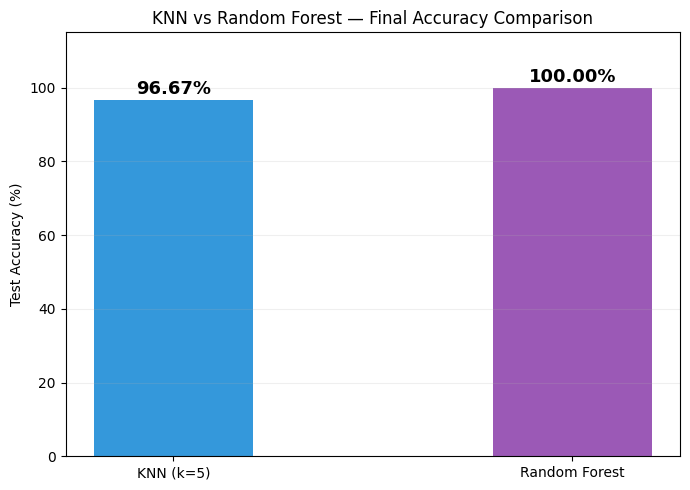


 KEY INSIGHTS
1. Petal length & petal width are the strongest features for classification.
2. Setosa is perfectly separable; Versicolor & Virginica have slight overlap.
3. Random Forest achieves higher accuracy than KNN on this dataset.
4. StandardScaler used for both models to ensure fair comparison.


In [39]:
results = pd.DataFrame({
    'Model'            : ['KNN (k=5)', 'Random Forest'],
    'Test Accuracy (%)': [round(knn_accuracy*100, 2), round(rf_accuracy*100, 2)]
})

print('        FINAL MODEL COMPARISON           ')
print(results.to_string(index=False))


fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    results['Model'],
    results['Test Accuracy (%)'],
    color=['#3498db', '#9b59b6'], width=0.4
)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('KNN vs Random Forest — Final Accuracy Comparison')
ax.set_ylim(0, 115)
for bar, val in zip(bars, results['Test Accuracy (%)']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1.5,
        f'{val:.2f}%', ha='center', fontsize=13, fontweight='bold'
    )
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

print('\n KEY INSIGHTS')
print('1. Petal length & petal width are the strongest features for classification.')
print('2. Setosa is perfectly separable; Versicolor & Virginica have slight overlap.')
print('3. Random Forest achieves higher accuracy than KNN on this dataset.')
print('4. StandardScaler used for both models to ensure fair comparison.')